# Refined Stage 3A - data characteristics and failure (RQ4)

**No GPU.** Everything here runs on the corrected Stage 2 results plus the raw series.

RQ4 asks whether differences in zero-shot performance can be explained by *measurable*
properties of the series. This is the strongest differentiator in the thesis: the competing
literature reports which model won; none of it explains failure from the data.

Four descriptors, all computable before any model runs:

| Descriptor | Definition | Hypothesis |
|---|---|---|
| zero-inflation | share of exact zeros | H4 — zeros degrade accuracy; aggregation removes them |
| volatility | coefficient of variation, sd / mean | high variance is harder |
| seasonal strength | autocorrelation at the dominant period `m` | strong cycles are learnable |
| **cycle coverage** | context duration / dominant period | H3 — a context shorter than one cycle cannot show the model the cycle |

Cycle coverage is the one that matters most and the one no prior study reports, because it
only becomes visible when granularity is treated as a variable.

In [1]:
import sys, os, warnings, importlib
warnings.filterwarnings("ignore")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import refined_stage_common as C

# A kernel that imported an older refined_stage_common keeps serving it from cache, and
# the failure surfaces much later as a missing column. Reload, then verify.
importlib.reload(C)
REQUIRED = "2026.09.10-relmae"
assert getattr(C, "__version__", None) == REQUIRED, (
    f"stale refined_stage_common (got {getattr(C, '__version__', 'none')}, "
    f"need {REQUIRED}) — restart the kernel and Run All")

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
PALETTE = {"chronos": "#2563eb", "timesfm": "#059669", "moirai": "#d97706"}
print(f"common module {C.__version__} from {C.__file__}")

common module 2026.09.10-relmae from e:\Thesis\EnergyForcastModel\refined_stage_common.py


In [2]:
DATA = C.get_data()
RESULTS = "refined_stage2_results.csv"
assert os.path.exists(RESULTS), "run refined_stage2_baseline.ipynb first"
res = pd.read_csv(RESULTS)
cl = C.clean(res)
print(f"{len(cl):,} scored windows")

loaded cached panel <- refined_panel_cache.pkl
  load   5 series, 230,736–232,272 points
  solar  5 series, 52,560–52,560 points
  wind   5 series, 434,876–434,876 points
1,245/1,350 windows used | 105 degenerate excluded
1,245 scored windows


## 1. Profile every series at every granularity

In [3]:
def acf_at(x, lag):
    if len(x) <= lag + 10:
        return np.nan
    a, b = x[:-lag], x[lag:]
    if np.std(a) < 1e-9 or np.std(b) < 1e-9:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

rows = []
for et in C.BASE:
    for gk in C.GRANULARITIES:
        m = C.seasonal_m(et, gk)
        d = C.step_minutes(et, gk)
        for sid, v in enumerate(C.panel(DATA, et, gk)):
            mean = float(np.mean(v))
            rows.append({
                "etype": et, "gran": gk, "series_id": sid,
                "n_points": len(v), "step_minutes": d, "m": m,
                "pct_zero": 100 * float(np.mean(v == 0)),
                "cv": float(np.std(v) / mean) if mean > 1e-9 else np.nan,
                "seasonal_strength": acf_at(v, m),
                "mean": mean, "std": float(np.std(v)),
            })
prof = pd.DataFrame(rows)
print(prof.groupby(["etype", "gran"])[["pct_zero", "cv", "seasonal_strength"]]
        .median().round(3).to_string())

              pct_zero     cv  seasonal_strength
etype gran                                      
load  1D         0.000  0.115              0.767
      1h         0.000  0.202              0.883
      native     0.000  0.203              0.883
solar 1D         0.000  0.377              0.248
      1h        51.804  1.458              0.853
      native    55.289  1.475              0.843
wind  1D        21.854  0.953              0.360
      1h        24.145  1.642              0.634
      native    24.245  1.676              0.617


## 2. Join the descriptors to accuracy

Cycle coverage is computed here because it depends on the context the run actually used,
which is recorded per window in the results file.

In [4]:
METRIC = "relMAE"      # horizon-matched; switch to "MASE" to reproduce the classic view
acc = (cl.groupby(["etype", "gran", "series_id", "model"])[[METRIC, "MASE"]]
         .median().reset_index().rename(columns={METRIC: "score"}))
ctx = (cl.groupby(["etype", "gran", "series_id"])
         .agg(context_steps=("context_steps", "first"),
              history_minutes=("history_minutes", "first")).reset_index())
df = acc.merge(prof, on=["etype", "gran", "series_id"]).merge(
     ctx, on=["etype", "gran", "series_id"])
df["cycle_coverage"] = df["context_steps"] / df["m"]
df["cycle_days"] = df["m"] * df["step_minutes"] / 1440
df["spans_cycle"] = df["cycle_coverage"] >= 1.0
print(df.groupby(["etype", "gran"])[["cycle_coverage", "pct_zero", "cv"]]
        .median().round(3).to_string())
df.to_csv("refined_stage3a_characteristics.csv", index=False)
print("\nsaved -> refined_stage3a_characteristics.csv")

              cycle_coverage  pct_zero     cv
etype gran                                   
load  1D              73.143     0.000  0.115
      1h              21.333     0.000  0.202
      native          10.667     0.000  0.203
solar 1D              32.143     0.000  0.377
      1h              21.333    51.804  1.458
      native           3.556    55.289  1.475
wind  1D              23.143    21.854  0.953
      1h              21.333    24.145  1.642
      native           0.356    22.532  1.466

saved -> refined_stage3a_characteristics.csv


## 3. H3 - does the context have to span the dominant cycle?

In [5]:
print("Median MASE by whether the context spans one full seasonal cycle:\n")
print(df.groupby("spans_cycle")["score"].agg(["median", "mean", "size"]).round(3).to_string())
print()
print(df.groupby(["etype", "gran"])
        .agg(coverage=("cycle_coverage", "median"), spans=("spans_cycle", "first"),
             median_score=("score", "median")).round(3).to_string())

Median MASE by whether the context spans one full seasonal cycle:

             median   mean  size
spans_cycle                     
False         1.008  0.973    12
True          0.948  1.129   120

              coverage  spans  median_score
etype gran                                 
load  1D        73.143   True         0.802
      1h        21.333   True         0.938
      native    10.667   True         1.002
solar 1D        32.143   True         0.830
      1h        21.333   True         0.985
      native     3.556   True         2.067
wind  1D        23.143   True         0.978
      1h        21.333   True         1.036
      native     0.356  False         1.008


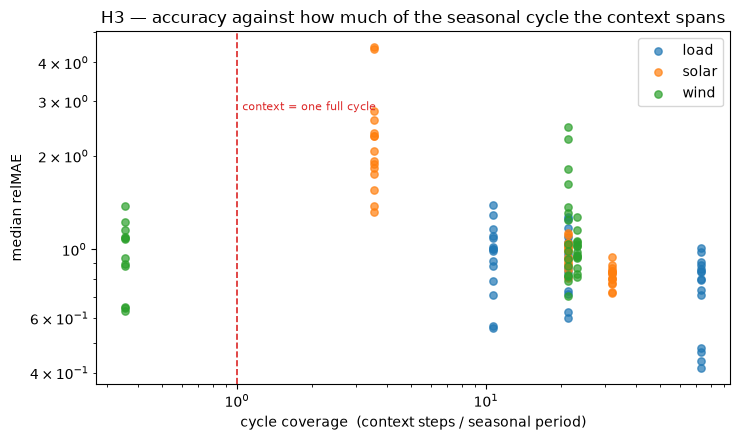

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for et, g in df.groupby("etype"):
    ax.scatter(g.cycle_coverage, g.score, label=et, alpha=0.7, s=28)
ax.axvline(1.0, color="#dc2626", ls="--", lw=1.2)
ax.text(1.05, ax.get_ylim()[1]*0.6, "context = one full cycle", color="#dc2626", fontsize=8)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("cycle coverage  (context steps / seasonal period)")
ax.set_ylabel(f"median {METRIC}"); ax.legend()
ax.set_title("H3 — accuracy against how much of the seasonal cycle the context spans")
plt.tight_layout(); plt.show()

## 4. H4 - zero-inflation, and whether aggregation reverses it

In [7]:
print("Solar is the natural experiment: the same physical signal at three resolutions.\n")
print(df[df.etype == "solar"].groupby("gran")
        .agg(pct_zero=("pct_zero", "median"), score=("score", "median")).round(3).to_string())

Solar is the natural experiment: the same physical signal at three resolutions.

        pct_zero  score
gran                   
1D         0.000  0.830
1h        51.804  0.985
native    55.289  2.067


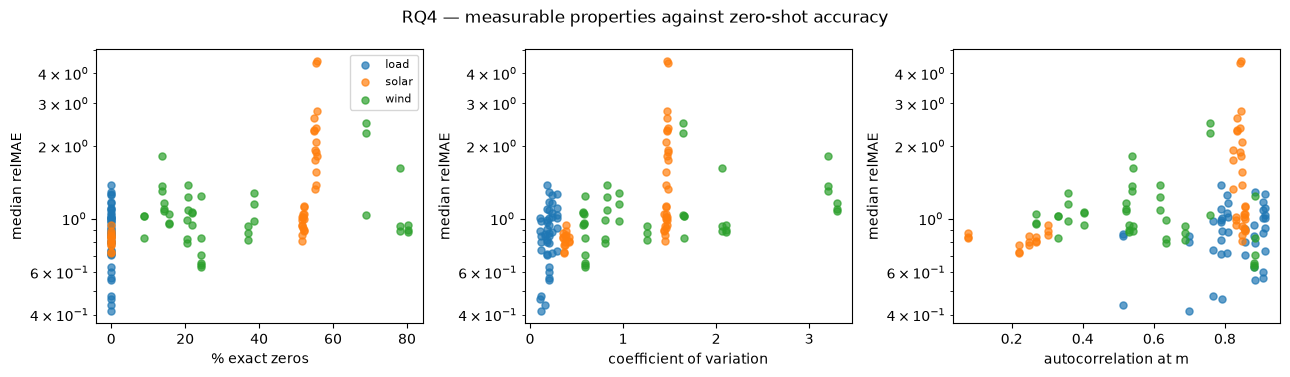

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (col, lab) in zip(axes, [("pct_zero", "% exact zeros"),
                                 ("cv", "coefficient of variation"),
                                 ("seasonal_strength", f"autocorrelation at m")]):
    for et, g in df.groupby("etype"):
        ax.scatter(g[col], g.score, label=et, alpha=0.7, s=26)
    ax.set_yscale("log"); ax.set_xlabel(lab); ax.set_ylabel(f"median {METRIC}")
axes[0].legend(fontsize=8)
plt.suptitle("RQ4 — measurable properties against zero-shot accuracy")
plt.tight_layout(); plt.show()

## 5. Which descriptor explains the most?

In [9]:
from scipy import stats
y = np.log10(df["score"].replace(0, np.nan))
print(f"Spearman rank correlation with log {METRIC} (rank-based, so outliers do not dominate):\n")
for col in ["cycle_coverage", "pct_zero", "cv", "seasonal_strength"]:
    ok = df[col].notna() & y.notna()
    rho, p = stats.spearmanr(df.loc[ok, col], y[ok])
    print(f"  {col:20s} rho = {rho:+.3f}   p = {p:.2e}   n = {ok.sum()}")

Spearman rank correlation with log relMAE (rank-based, so outliers do not dominate):

  cycle_coverage       rho = -0.473   p = 1.04e-08   n = 132
  pct_zero             rho = +0.498   p = 1.22e-09   n = 132
  cv                   rho = +0.513   p = 3.16e-10   n = 132
  seasonal_strength    rho = +0.085   p = 3.34e-01   n = 132


In [10]:
# a small interpretable model — deliberately not a black box, that is the point vs TimeTic
import statsmodels.api as sm
X = df[["cycle_coverage", "pct_zero", "cv", "seasonal_strength"]].copy()
X["cycle_coverage"] = np.log10(X["cycle_coverage"].clip(lower=1e-3))
ok = X.notna().all(axis=1) & y.notna()
fit = sm.OLS(y[ok], sm.add_constant(X[ok])).fit()
print(fit.summary().tables[1])
print(f"\nR-squared = {fit.rsquared:.3f} on {int(ok.sum())} series-granularity-model rows")

                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.0961      0.060     -1.610      0.110      -0.214       0.022
cycle_coverage       -0.0299      0.024     -1.243      0.216      -0.077       0.018
pct_zero              0.0020      0.001      2.897      0.004       0.001       0.003
cv                    0.0450      0.023      1.935      0.055      -0.001       0.091
seasonal_strength     0.0759      0.057      1.322      0.189      -0.038       0.190

R-squared = 0.300 on 132 series-granularity-model rows


## 6. Writing this up

State the rule you find in terms an operator can apply without running a model — for
example: *profile the signal, find the dominant period, check whether your intended context
covers it, and check the share of exact zeros.* Cite TimeTic (arXiv:2509.23695) and
differentiate: they build a general learned predictor of fine-tuned performance for model
selection across domains; this is an energy-specific test of whether a few interpretable
descriptors explain zero-shot deployability.

Next: `refined_stage3b_context_sweep` (GPU).